Thử dựa vào bài lab tuần trước và thử trên tập dữ lieu khác 
- Cat and dog và thỏa điểu kiện sao cho độ chính xác trên 90% các bạn có thể thay thế tham số đầu vào

Epoch 1
Train Acc: 60.31% | Val Acc: 61.25%
Epoch 2
Train Acc: 62.99% | Val Acc: 65.60%
Epoch 3
Train Acc: 67.56% | Val Acc: 67.03%
Epoch 4
Train Acc: 68.78% | Val Acc: 67.23%
Epoch 5
Train Acc: 71.91% | Val Acc: 71.73%
Epoch 6
Train Acc: 74.67% | Val Acc: 73.36%
Epoch 7
Train Acc: 76.64% | Val Acc: 76.42%
Epoch 8
Train Acc: 75.78% | Val Acc: 75.04%
Epoch 9
Train Acc: 78.09% | Val Acc: 79.09%
Epoch 10
Train Acc: 78.73% | Val Acc: 78.60%
Epoch 11
Train Acc: 82.04% | Val Acc: 81.31%
Epoch 12
Train Acc: 84.11% | Val Acc: 83.24%
Epoch 13
Train Acc: 84.50% | Val Acc: 84.58%
Epoch 14
Train Acc: 84.82% | Val Acc: 84.23%
Epoch 15
Train Acc: 87.21% | Val Acc: 86.41%
Epoch 16
Train Acc: 84.07% | Val Acc: 82.65%
Epoch 17
Train Acc: 84.81% | Val Acc: 86.01%
Epoch 18
Train Acc: 86.83% | Val Acc: 86.11%
Epoch 19
Train Acc: 88.07% | Val Acc: 87.64%
Epoch 20
Train Acc: 84.35% | Val Acc: 84.48%
Epoch 21
Train Acc: 89.84% | Val Acc: 88.53%
Epoch 22
Train Acc: 88.17% | Val Acc: 86.90%
Epoch 23
Train Acc:

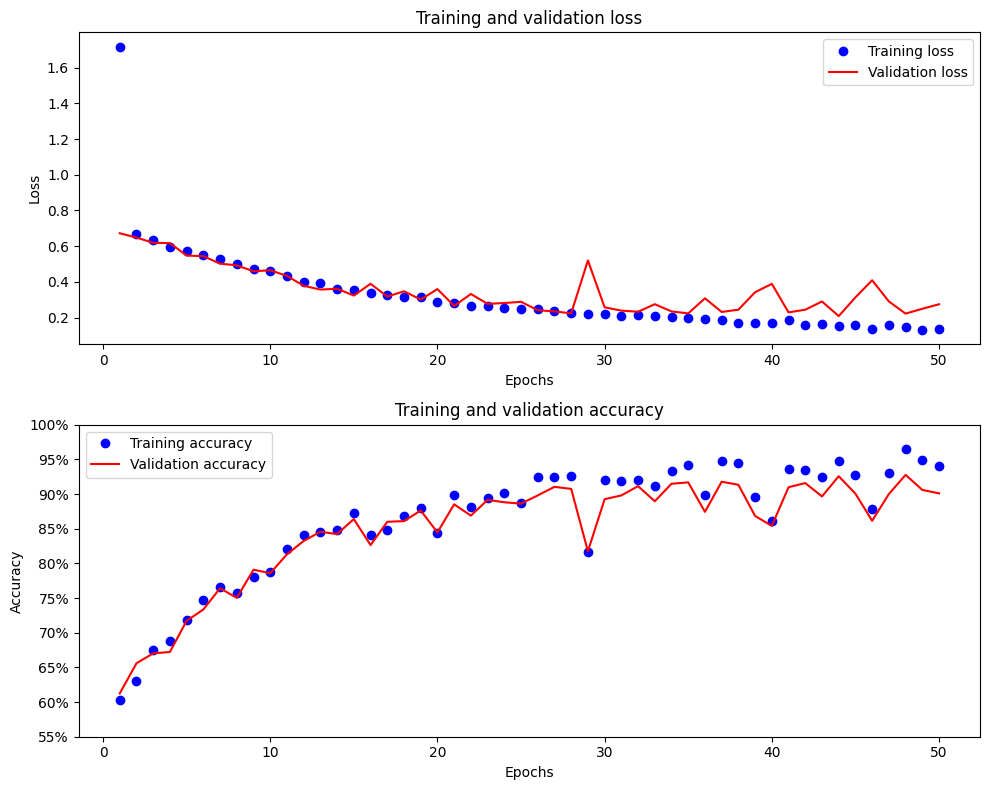

In [ ]:
import torch 
import torch.nn as nn 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker 
from torch.utils.data import Dataset, DataLoader 
from torchvision import datasets, transforms 
from torch.optim import Adam 
import os

get_ipython().run_line_magic('matplotlib', 'inline')
device = 'cuda' if torch.cuda.is_available() else 'cpu' 
data_path = 'Cat_and_Dog' 
img_size = 128
train_preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

val_preprocess = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])
train_raw = datasets.ImageFolder(os.path.join(data_path, 'training_set'), transform=train_preprocess)
val_raw = datasets.ImageFolder(os.path.join(data_path, 'test_set'), transform=val_preprocess)

class FMNISTDataset(Dataset): 
    def __init__(self, raw_dataset): 
        self.dataset = raw_dataset
    def __getitem__(self, ix): 
        x, y = self.dataset[ix]  
        return x.to(device), torch.tensor(y).to(device) 
    def __len__(self):  
        return len(self.dataset) 

def get_model(): 
    model = nn.Sequential( 
        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(256 * (img_size // 16) * (img_size // 16), 512), 
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 2)
    ).to(device) 

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=5e-4) 
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn): 
    model.train() 
    prediction = model(x) 
    batch_loss = loss_fn(prediction, y) 
    batch_loss.backward() 
    opt.step()
    opt.zero_grad() 
    return batch_loss.item() 

def accuracy(x, y, model): 
    model.eval() 
    with torch.no_grad(): 
        prediction = model(x) 
    max_values, argmaxes = prediction.max(-1) 
    is_correct = argmaxes == y 
    return is_correct.cpu().numpy().tolist() 

def get_data():  
    train = FMNISTDataset(train_raw)  
    trn_dl = DataLoader(train, batch_size=128, shuffle=True) 
    val = FMNISTDataset(val_raw)  
    val_dl = DataLoader(val, batch_size=128, shuffle=False)
    return trn_dl, val_dl 

@torch.no_grad() 
def val_loss(x, y, model): 
    prediction = model(x) 
    v_loss = loss_fn(prediction, y) 
    return v_loss.item() 

trn_dl, val_dl = get_data() 
model, loss_fn, optimizer = get_model() 

train_losses, train_accuracies = [], [] 
val_losses, val_accuracies = [], [] 

for epoch in range(50):
    print(f"Epoch {epoch+1}") 
    train_epoch_losses, train_epoch_accuracies = [], [] 
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        batch_loss = train_batch(x, y, model, optimizer, loss_fn) 
        train_epoch_losses.append(batch_loss)  

    train_epoch_loss = np.array(train_epoch_losses).mean() 

    # Tính Accuracy
    for ix, batch in enumerate(iter(trn_dl)): 
        x, y = batch 
        is_correct = accuracy(x, y, model) 
        train_epoch_accuracies.extend(is_correct) 
    train_epoch_accuracy = np.mean(train_epoch_accuracies) 

    # Validation
    val_epoch_accuracies = []
    val_epoch_losses = []
    for ix, batch in enumerate(iter(val_dl)): 
        x, y = batch 
        val_is_correct = accuracy(x, y, model) 
        val_epoch_accuracies.extend(val_is_correct)
        validation_loss = val_loss(x, y, model) 
        val_epoch_losses.append(validation_loss)

    train_losses.append(train_epoch_loss) 
    train_accuracies.append(train_epoch_accuracy) 
    val_losses.append(np.mean(val_epoch_losses)) 
    val_accuracies.append(np.mean(val_epoch_accuracies)) 
    print(f"Train Acc: {train_epoch_accuracy*100:.2f}% | Val Acc: {np.mean(val_epoch_accuracies)*100:.2f}%")

epochs = np.arange(50)+1 

plt.figure(figsize=(10, 8))
plt.subplot(211) 
plt.plot(epochs, train_losses, 'bo', label='Training loss') 
plt.plot(epochs, val_losses, 'r', label='Validation loss') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10)) 
plt.title('Training and validation loss') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
plt.subplot(212) 

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy') 
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy') 
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10)) 
plt.title('Training and validation accuracy') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
ticks = plt.gca().get_yticks()
plt.gca().set_yticks(ticks)
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in ticks])  
plt.legend() 
plt.tight_layout()
plt.show()

In [3]:
all_test_accuracies = []
model.eval()
for ix, batch in enumerate(iter(val_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    all_test_accuracies.extend(is_correct)
final_test_acc = np.mean(all_test_accuracies) * 100

print(f"\nĐộ chính xác trên tập test: {final_test_acc:.2f}%")


Độ chính xác trên tập test: 90.11%
